# Panel Regression Analysis: Welfare State and Democratic Resilience

## Description

This notebook implements a comprehensive panel regression experiment.


In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0')

print('Dependencies installed')


Dependencies installed



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s|%(levelname)s|%(message)s')
logger = logging.getLogger(__name__)
print('Imports complete')


Imports complete


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-f1091c-welfare-state-generosity-and-the-inequal/main/round-2/experiment-1/demo/mini_demo_data.json"

import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception as e:
        print(f"GitHub load failed: {e}")
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

print('Data loading helper defined')


Data loading helper defined


In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'][0]['examples'])} examples")


GitHub load failed: HTTP Error 404: Not Found
Loaded data with 20 examples


## Data Preparation

Convert JSON data to pandas DataFrame.


In [5]:
def prepare_data(data):
    examples = data['datasets'][0]['examples']
    rows = []
    for ex in examples:
        inp = json.loads(ex['input'])
        rows.append({
            'country': inp['country'],
            'year': int(inp['year']),
            'gini_coeff': inp.get('gini_coeff'),
            'social_spending_gdp': inp.get('social_spending_gdp'),
            'vdem_index': float(ex['output']),
            'social_spending_gdp_lag1': inp.get('social_spending_gdp_lag1')
        })
    df = pd.DataFrame(rows)
    if df['gini_coeff'].max() > 1:
        df['gini_coeff'] = df['gini_coeff'] / 100
    countries = sorted(df['country'].unique())
    cid_map = {c: i for i, c in enumerate(countries)}
    df['country_id'] = df['country'].map(cid_map)
    return df

df = prepare_data(data)
print(f"DataFrame: {len(df)} rows, {len(df['country'].unique())} countries")
df.head()


DataFrame: 20 rows, 8 countries


,country,year,gini_coeff,social_spending_gdp,vdem_index,social_spending_gdp_lag1,country_id
0,Colombia,2012,0.4630,5.691,0.657,12.625,1
1,Mexico,1996,0.5292,3.367,0.515,2.402,6
2,Mexico,2005,0.4569,2.038,0.707,6.145,6
3,Mexico,2006,0.4710,6.260,0.670,4.262,6
4,Mexico,1994,0.5020,3.078,0.474,1.014,6


## Descriptive Statistics

Calculate summary statistics.


In [6]:
print('Descriptive Statistics:')
print('='*60)
for col in ['gini_coeff', 'social_spending_gdp', 'vdem_index', 'social_spending_gdp_lag1']:
    if col in df.columns:
        data = df[col].dropna()
        if len(data) > 0:
            print(f"\n{col}:")
            print(f"  Mean: {data.mean():.4f}")
            print(f"  Std: {data.std():.4f}")
            print(f"  N: {len(data)}")
            print(f"  Missing: {df[col].isna().sum()}")


Descriptive Statistics:

gini_coeff:
  Mean: 0.4532
  Std: 0.0683
  N: 20
  Missing: 0

social_spending_gdp:
  Mean: 5.5186
  Std: 2.8350
  N: 12
  Missing: 8

vdem_index:
  Mean: 0.5788
  Std: 0.1386
  N: 20
  Missing: 0

social_spending_gdp_lag1:
  Mean: 5.4146
  Std: 4.0343
  N: 12
  Missing: 8


## Missing Data Analysis

Examine missing data patterns.


In [7]:
missing = {}
for col in df.columns:
    if col in ['country', 'country_id']: continue
    n = int(df[col].isna().sum())
    missing[col] = {'count': n, 'pct': float(n/len(df)*100)}

print('Missing Data:')
for col, info in missing.items():
    print(f"  {col}: {info['count']} ({info['pct']:.1f}%)")


Missing Data:
  year: 0 (0.0%)
  gini_coeff: 0 (0.0%)
  social_spending_gdp: 8 (40.0%)
  vdem_index: 0 (0.0%)
  social_spending_gdp_lag1: 8 (40.0%)


## Correlation Analysis

Calculate correlations between key variables.


In [8]:
cols = ['vdem_index', 'gini_coeff', 'social_spending_gdp_lag1']
cols = [c for c in cols if c in df.columns]
df_corr = df[cols].dropna()

if len(df_corr) >= 10:
    corr = df_corr.corr()
    print('Correlation Matrix:')
    print(corr.round(4))
else:
    print(f'Insufficient data for correlation: {len(df_corr)} complete cases')


Correlation Matrix:
                          vdem_index  gini_coeff  social_spending_gdp_lag1
vdem_index                    1.0000     -0.4832                    0.4440
gini_coeff                   -0.4832      1.0000                   -0.5056
social_spending_gdp_lag1      0.4440     -0.5056                    1.0000


## Regression Analysis

Run pooled OLS regression.


In [9]:
# Pooled OLS - simplified version
df_reg = df.dropna(subset=['vdem_index', 'gini_coeff', 'social_spending_gdp_lag1'])
print(f'Complete cases for regression: {len(df_reg)}')

if len(df_reg) >= 5:
    X = add_constant(df_reg[['gini_coeff', 'social_spending_gdp_lag1']])
    y = df_reg['vdem_index']
    model = OLS(y, X).fit()
    print('\nPooled OLS Results:')
    print(model.summary())
    
    # Store results for later use
    reg_results = {'pooled_ols': {'n': len(df_reg), 'r_squared': float(model.rsquared)}}
    print(f'\nR-squared: {model.rsquared:.4f}')
else:
    print('Insufficient data for regression')


Complete cases for regression: 12

Pooled OLS Results:
                            OLS Regression Results                            
Dep. Variable:             vdem_index   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.129
Method:                 Least Squares   F-statistic:                     1.812
Date:                Sat, 13 Jun 2026   Prob (F-statistic):              0.218
Time:                        23:39:11   Log-Likelihood:                 17.275
No. Observations:                  12   AIC:                            -28.55
Df Residuals:                       9   BIC:                            -27.09
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

## Sample Attrition

Compare complete case vs full sample.


In [10]:
total = len(df)
complete = len(df.dropna(subset=['vdem_index', 'gini_coeff', 'social_spending_gdp_lag1']))
print(f'Original N: {total}')
print(f'Complete case N: {complete}')
print(f'Attrition rate: {(total-complete)/total*100:.1f}%')


Original N: 20
Complete case N: 12
Attrition rate: 40.0%


## Visualization

Create plots to visualize the relationships.


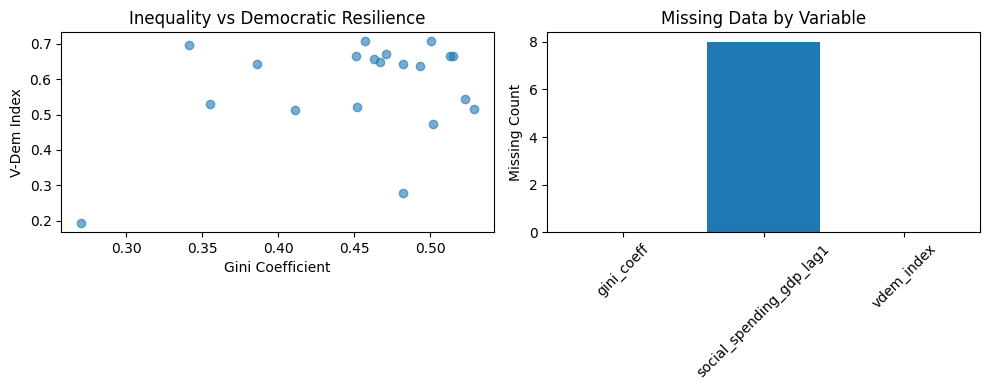


SUMMARY
Pooled OLS R-squared: 0.2870


In [11]:
import matplotlib.pyplot as plt

# Scatter plot: Gini vs V-Dem
df_plot = df.dropna(subset=['vdem_index', 'gini_coeff'])
if len(df_plot) > 0:
    plt.figure(figsize=(10, 4))
    
    # Plot 1: Gini vs V-Dem
    plt.subplot(1, 2, 1)
    plt.scatter(df_plot['gini_coeff'], df_plot['vdem_index'], alpha=0.6)
    plt.xlabel('Gini Coefficient')
    plt.ylabel('V-Dem Index')
    plt.title('Inequality vs Democratic Resilience')
    
    # Plot 2: Missing data
    plt.subplot(1, 2, 2)
    missing_counts = df.isna().sum()[['gini_coeff', 'social_spending_gdp_lag1', 'vdem_index']]
    plt.bar(range(len(missing_counts)), missing_counts.values)
    plt.xticks(range(len(missing_counts)), missing_counts.index, rotation=45)
    plt.ylabel('Missing Count')
    plt.title('Missing Data by Variable')
    
    plt.tight_layout()
    plt.show()

# Print summary
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
if 'reg_results' in locals():
    print(f"Pooled OLS R-squared: {reg_results['pooled_ols']['r_squared']:.4f}")
